In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


connecting to google drive

In [65]:
import pandas as pd 
import numpy as np

data = pd.read_csv("/content/drive/MyDrive/car_price.csv")
data =data.dropna(subset=["price"])
data["car_age"] = 2026 - data["year"]
data = data.drop("year" , axis=1)
data["miles_per_year"] = data["mileage"] / (data["car_age"] + 1)   # mile per year feature
data["engine_age_impact"] = data["engineSize"] * data["car_age"] # new feature to show how the engine size is impacted in older cars  
data.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,miles_per_year,engine_age_impact
0,A1,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi,9.0,1573.500000,12.6
1,A6,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi,10.0,3291.181818,20.0
2,A1,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi,10.0,2722.363636,14.0
3,A4,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi,9.0,2595.200000,18.0
4,A3,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi,7.0,249.750000,7.0


fuel Type , transmission , make , and model are strings that need to be onehot encoded

carage , engine size , milage , mpg , tax need to be normalized

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68814 entries, 0 to 72434
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              65370 non-null  object 
 1   price              68814 non-null  float64
 2   transmission       65355 non-null  object 
 3   mileage            65389 non-null  float64
 4   fuelType           65353 non-null  object 
 5   tax                65390 non-null  float64
 6   mpg                65381 non-null  float64
 7   engineSize         65356 non-null  float64
 8   Make               65365 non-null  object 
 9   car_age            65352 non-null  float64
 10  miles_per_year     62139 non-null  float64
 11  engine_age_impact  62064 non-null  float64
dtypes: float64(8), object(4)
memory usage: 6.8+ MB


In [67]:
data.describe()

,price,mileage,tax,mpg,engineSize,car_age,miles_per_year,engine_age_impact
count,68814.000000,65389.000000,65390.000000,65381.000000,65356.000000,65352.000000,62139.000000,62064.000000
mean,16583.919261,23188.949043,116.977978,55.823222,1.635574,8.924287,2119.125432,14.626835
std,9304.412707,21362.415899,64.108277,17.123016,0.560911,2.103071,1659.126951,6.397296
min,495.000000,1.000000,0.000000,0.300000,0.000000,6.000000,0.052632,0.000000
25%,10167.250000,7164.000000,30.000000,47.900000,1.200000,7.000000,838.229167,10.500000
50%,14495.000000,17526.000000,145.000000,55.400000,1.600000,9.000000,1785.833333,14.000000
75%,20359.750000,32500.000000,145.000000,62.800000,2.000000,10.000000,3006.303030,18.000000
max,145000.000000,323000.000000,580.000000,470.800000,6.600000,30.000000,17000.000000,121.800000


In [68]:
data["Make"].value_counts()

,count
Make,
Ford,16142
vw,13698
BMW,9737
audi,9668
toyota,6065
skoda,5666
Hyundai,4389


In [69]:
data["fuelType"].value_counts()

,count
fuelType,
Petrol,36483
Diesel,26052
Hybrid,2605
Other,208
Electric,5


In [70]:
data["transmission"].value_counts()

,count
transmission,
Manual,38748
Semi-Auto,13892
Automatic,12711
Other,4


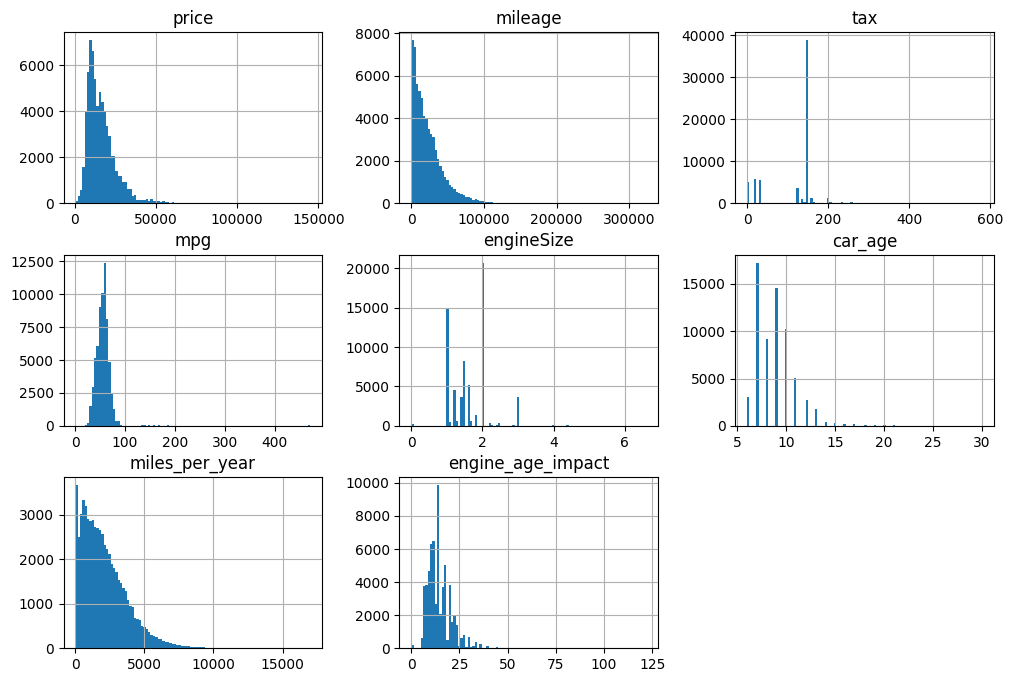

In [71]:
import matplotlib.pyplot as plt

data.hist(bins=100 , figsize=(12,8))

plt.show()

Splitting the data 

In [72]:
from sklearn.model_selection import train_test_split

x_reg = data.drop("price" , axis = 1)
y_reg = data["price"]

x_train_raw_reg , x_test_raw_reg , y_train_reg , y_test_reg  = train_test_split(x_reg , y_reg , test_size=0.2 , random_state=42)

In [73]:
corr_mat = data.corr(numeric_only=True)

corr_mat["mileage"].sort_values(ascending=False) # strong coolition between the mileage and the car age

,mileage
mileage,1.000000
miles_per_year,0.962625
car_age,0.748660
engine_age_impact,0.540092
mpg,0.181092
engineSize,0.122749
tax,-0.232608
price,-0.427524


In [74]:
corr_mat["mpg"].sort_values(ascending=False)  # strong negative coolition between the mpg and the tax

,mpg
mpg,1.000000
miles_per_year,0.220308
mileage,0.181092
car_age,0.146617
engine_age_impact,-0.142090
engineSize,-0.280506
price,-0.335615
tax,-0.425346


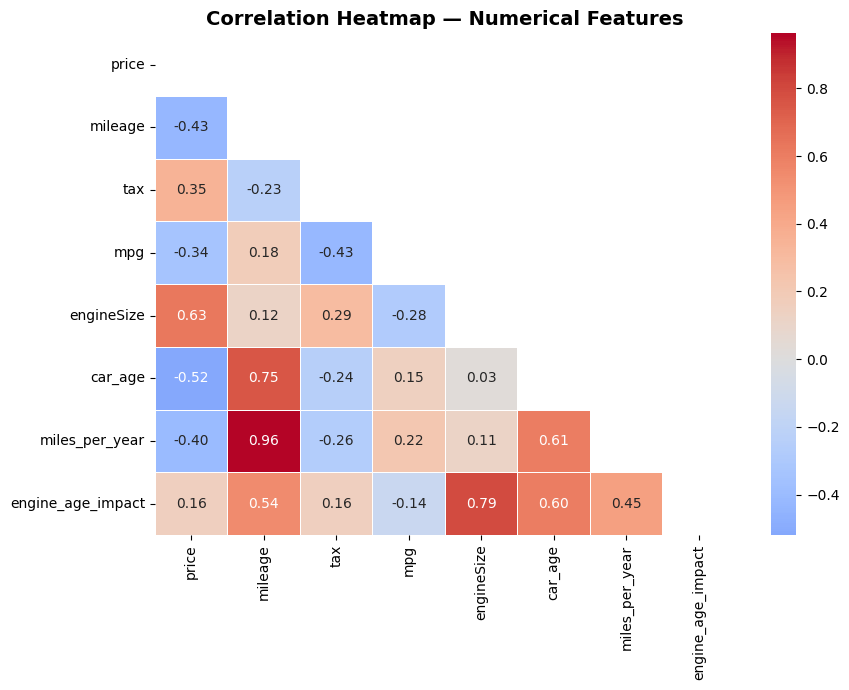

In [75]:
import seaborn as sns

num_cols = [col for col in data.select_dtypes(include=np.number)]

corr = data[num_cols].corr()    # colletion heat map between data

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Box plot for the data

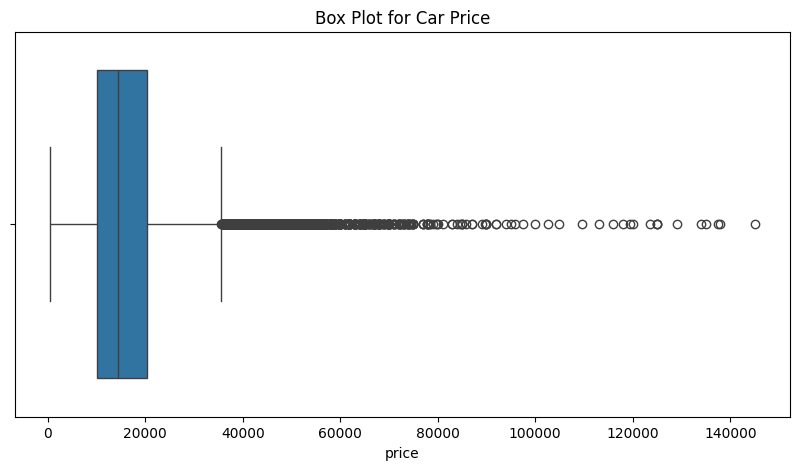

In [76]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
sns.boxplot(x=data["price"])
plt.title("Box Plot for Car Price")
plt.show()

## data has been splitted to both a test set and a train set using train_test_split function 
## used the imputer to add the median to all null values in numerical attribute
## used the imputer to add the most frequent str value to the null values
## onehotencoded all the str values using the onehotencoder function
## Used the minmax scaler to scale all the numerical values to be ranging from (-1 - 1 ) by subtracting the min value from all the values then dividing by the diffrence between the min and the max values
## Creating a pipeline for the all data transformation 

In [77]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

log_att = ["mpg" , "mileage" , "miles_per_year"]

other_num_att = [col for col in data.select_dtypes(include= np.number).columns if col not in log_att and col != "price"]   #every numerical attribuute that is not getting logged

log_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy="median")) , 
     ("log" , FunctionTransformer(np.log1p , inverse_func=np.expm1 , feature_names_out="one-to-one")) , 
     ("scale" , MinMaxScaler(feature_range=(-1 , 1)))
    ])  # logging attributes with right tail to become more of a normal distribution

num_pipeline = Pipeline([
              ("impute" , SimpleImputer(strategy="median")) , 
              ("standardize" , MinMaxScaler(feature_range=(-1 , 1)))  # created a pipeline for the numerical data transformations (handeling nulls and scaling)
])

cat_pipeline = Pipeline([
    ("strimputer" , SimpleImputer(strategy="most_frequent")), 
    ("onehot" , OneHotEncoder(handle_unknown="ignore"))
])


In [78]:
from sklearn.compose import make_column_selector , make_column_transformer


preproccesing = make_column_transformer(
    (log_pipeline , log_att) ,
    (num_pipeline , other_num_att) ,  
    (cat_pipeline , make_column_selector(dtype_include=object)) 
)

y_train_reg = np.log(y_train_reg)
y_test_reg = np.log(y_test_reg)

x_train_array_reg = preproccesing.fit_transform(x_train_raw_reg)

x_test_array_reg = preproccesing.transform(x_test_raw_reg)

feature_names = preproccesing.get_feature_names_out()

x_train_reg = pd.DataFrame(x_train_array_reg.toarray(), columns=feature_names, index=x_train_raw_reg.index) # type: ignore
x_test_reg = pd.DataFrame(x_test_array_reg.toarray(), columns=feature_names, index=x_test_raw_reg.index) # type: ignore


print(f"Training samples: {x_train_reg.shape[0]}")
print(f"Test samples:     {x_test_reg.shape[0]}")

Training samples: 55051
Test samples:     13763


## the price is our target value (what we want to predict) and it was included in the data as a numerical column so we dropped it from our features (x) and stored it seperately in (y) our target 


In [79]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train_reg , y_train_reg)    
print("model trained successfully")

model trained successfully


In [80]:
from sklearn.metrics import mean_squared_error  , mean_absolute_error

y_train_pred_reg = model.predict(x_train_reg)
y_test_pred_reg = model.predict(x_test_reg)

mse_train = mean_squared_error(y_train_reg , y_train_pred_reg)   
mae_train = mean_absolute_error(y_train_reg , y_train_pred_reg)

mse_test = mean_squared_error(y_test_reg , y_test_pred_reg)
mae_test = mean_absolute_error(y_test_reg , y_test_pred_reg)


print(f"Training MSE: {mse_train:.4f} | Test : {mse_test:.4f}")
print(f"Training MAE: {mae_train:.4f} | Test : {mae_test:.4f}")

Training MSE: 0.0269 | Test : 0.0272
Training MAE: 0.1191 | Test : 0.1198


PREDICTED VS ACTUAL SCATTER PLOT 

Text(0.5, 1.0, 'Linear Regression: Predicted vs Actual Car Price')

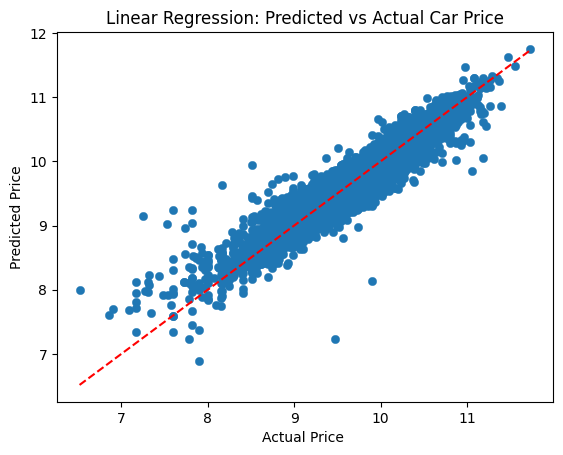

In [81]:
import matplotlib.pyplot as plt
plt.scatter(y_test_reg , y_test_pred_reg, linewidths=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()]
         , color='red', linestyle='--')

plt.xlabel('Actual Price ')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Predicted vs Actual Car Price')


splitted the data to 3 categories based on the price

In [82]:
data = data.copy()

data.loc[:, "price_category"] = pd.qcut(
    data["price"],
    q=3,
    labels=["Cheap", "Moderate", "Expensive"]
)

In [83]:
x_knn = data.drop(columns=["price", "price_category"])
y_knn = data["price_category"]


### Separate features (X) from the target variable (price_category).
### We remove the original price column to avoid data leakage.

In [84]:
from sklearn.model_selection import train_test_split

x_train_knn, x_test_knn, y_train_knn, y_test_knn = train_test_split(
    x_knn, y_knn,
    test_size=0.2,
    random_state=42
)

In [85]:
preproccesing.fit(x_train_knn)

x_train_knn = preproccesing.transform(x_train_knn)
x_test_knn = preproccesing.transform(x_test_knn)

## knn model

In [86]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_knn, y_train_knn)

KNeighborsClassifier()

 Train a K-Nearest Neighbors (KNN) classifier using the training data.
#### KNN predicts the class based on the closest data points in the feature space.

In [87]:
y_pred_knn = knn.predict(x_test_knn)

In [88]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_knn, y_pred_knn))
print(confusion_matrix(y_test_knn, y_pred_knn))

              precision    recall  f1-score   support

       Cheap       0.90      0.89      0.89      4537
   Expensive       0.90      0.91      0.90      4581
    Moderate       0.81      0.81      0.81      4645

    accuracy                           0.87     13763
   macro avg       0.87      0.87      0.87     13763
weighted avg       0.87      0.87      0.87     13763

[[4034   22  481]
 [  10 4161  410]
 [ 447  455 3743]]


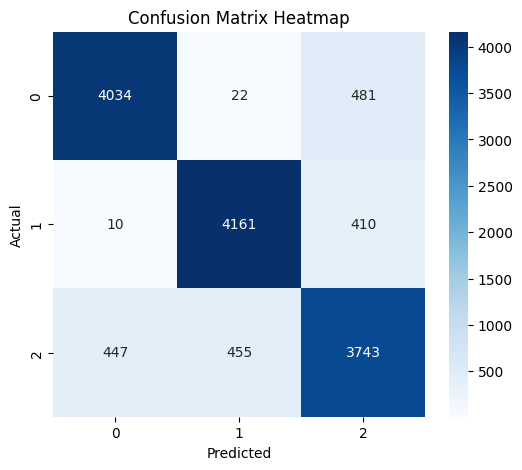

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_knn, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

 Evaluate model performance using classification metrics:
 - Precision
 - Recall
 - F1-score
  Also evaluate overall accuracy of the model.

In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {        # possible param to search into
    'n_neighbors': [3, 5, 7, 9, 11],    
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

 Define the hyperparameter space for KNN including:
- Number of neighbors (K)
 - Distance metrics (Euclidean and Manhattan)
 This allows the model to test different configurations.

 Initialize GridSearchCV to perform exhaustive search over the defined hyperparameter space.
 Cross-validation (cv=5) is used to ensure robust evaluation and avoid overfitting.

In [ ]:
grid_search.fit(x_train_knn, y_train_knn)

 Fit the GridSearch model on the training data.
 The model will evaluate multiple combinations of hyperparameters using cross-validation.

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7}
Best CV Accuracy: 0.8328278046781886


In [ ]:
best_knn_model = grid_search.best_estimator_
y_pred_knn = best_knn_model.predict(x_test_knn)

In [ ]:
print(classification_report(y_test_knn, y_pred_knn))

              precision    recall  f1-score   support

       Cheap       0.87      0.86      0.87      4537
   Expensive       0.88      0.87      0.88      4581
    Moderate       0.76      0.77      0.76      4645

    accuracy                           0.84     13763
   macro avg       0.84      0.84      0.84     13763
weighted avg       0.84      0.84      0.84     13763



In [ ]:
cm = confusion_matrix(y_test_knn, y_pred_knn)
print(cm)

[[3918   36  583]
 [  23 4004  554]
 [ 555  516 3574]]


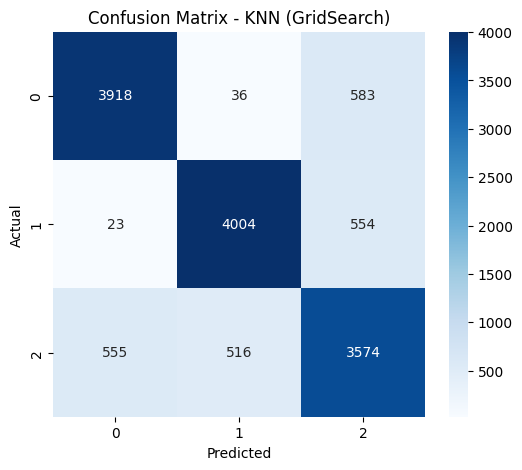

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN (GridSearch)")
plt.show()

# Plots

plot 1 demonstrates how each knn neighbors accuracy is justu=ifying the grid best search

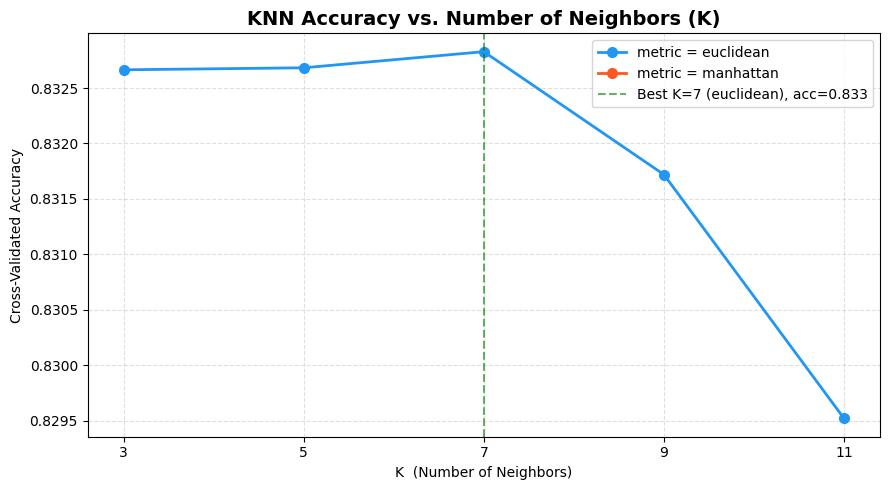

In [ ]:
k_values = [3, 5, 7, 9, 11]
metrics = ['euclidean', 'manhattan']
colors  = ['#2196F3', '#FF5722']

plt.figure(figsize=(9, 5))

for metric, color in zip(metrics, colors):     # loop through each and evcery neighbor then plots it
    scores = []
    for k in k_values:
        mask = (
            (np.array(grid_search.cv_results_['param_n_neighbors']) == k) &
            (np.array(grid_search.cv_results_['param_metric'])      == metric)
        )
        scores.append(grid_search.cv_results_['mean_test_score'][mask][0])
    plt.plot(k_values, scores, marker='o', label=f'metric = {metric}',
             color=color, linewidth=2, markersize=7)

best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
best_score = grid_search.best_score_

plt.axvline(best_k, linestyle='--', color='green', alpha=0.6,
            label=f'Best K={best_k} ({best_metric}), acc={best_score:.3f}')

plt.title('KNN Accuracy vs. Number of Neighbors (K)', fontsize=14, fontweight='bold')
plt.xlabel('K  (Number of Neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plot 2 is a histogram that shows how many car fall in each category

they are approximately the same height which shows that the knn is good

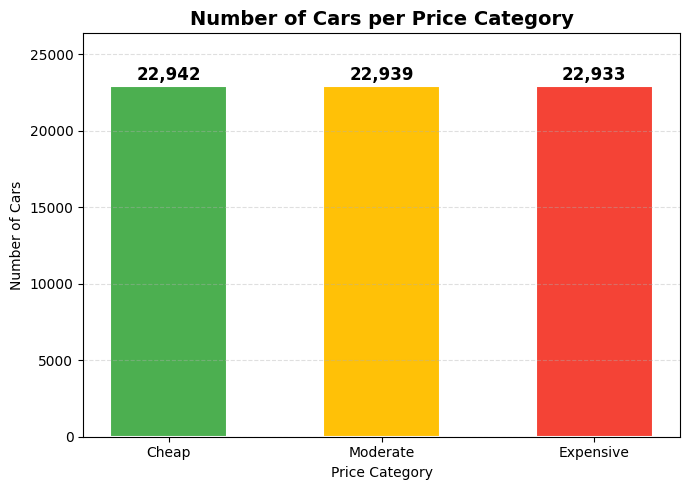

In [ ]:
category_counts = data['price_category'].value_counts().reindex(
    ['Cheap', 'Moderate', 'Expensive']
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    category_counts.index,
    category_counts.values,
    color=['#4CAF50', '#FFC107', '#F44336'],
    edgecolor='white', linewidth=1.5, width=0.55
)

for bar, val in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 150,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Number of Cars per Price Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Category')
ax.set_ylabel('Number of Cars')
ax.set_ylim(0, category_counts.max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



plot 3 demonstrates weather the error is normally distributed or not (biased or not)

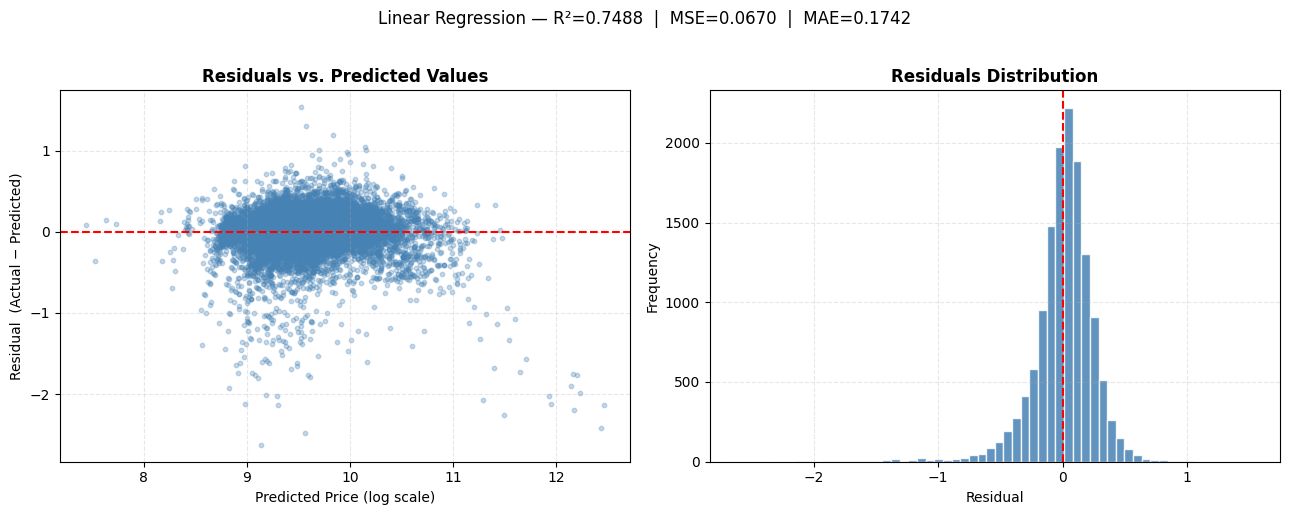

In [ ]:
from sklearn.metrics import r2_score

residuals = y_test_reg - y_test_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_pred_reg, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price (log scale)')
axes[0].set_ylabel('Residual  (Actual − Predicted)')
axes[0].set_title('Residuals vs. Predicted Values', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Right: residuals histogram
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

r2  = r2_score(y_test_reg, y_test_pred_reg)
mse = mean_squared_error(y_test_reg, y_test_pred_reg)
mae = mean_absolute_error(y_test_reg, y_test_pred_reg)
fig.suptitle(
    f'Linear Regression — R²={r2:.4f}  |  MSE={mse:.4f}  |  MAE={mae:.4f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()



plot 4 shows how scalling in the knn help by comparing the scalled version vs the unscaled version

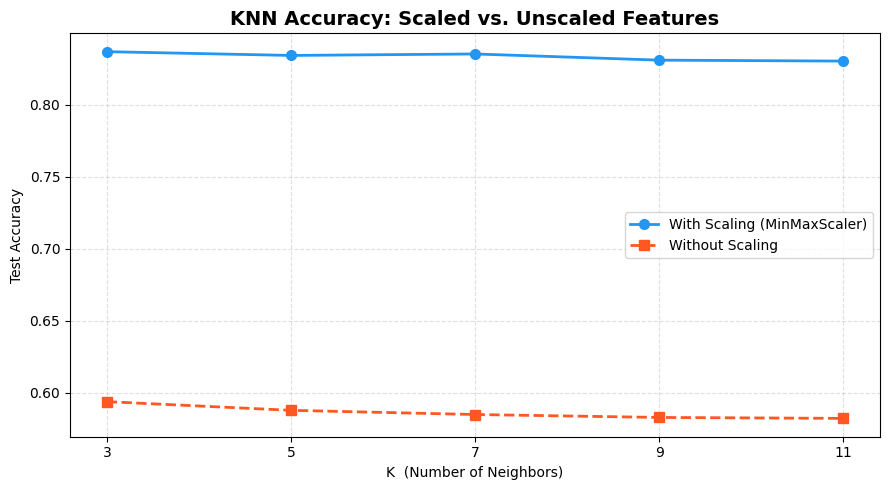

In [ ]:
from sklearn.metrics import accuracy_score


num_pipeline_noscale = Pipeline([                # redid the pipeline withouth the scaller or the logging of numerical att
    ("impute", SimpleImputer(strategy="median"))

])

prep_noscale = make_column_transformer(
    (num_pipeline_noscale, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

x_train_knn_noscale, x_test_knn_noscale, y_train_knn_noscale, y_test_knn_noscale = train_test_split(
    x_knn, y_knn, test_size=0.2, random_state=42)


prep_noscale.fit(x_train_knn_noscale)
x_train_knn_noscale = prep_noscale.transform(x_train_knn_noscale)
x_test_knn_noscale = prep_noscale.transform(x_test_knn_noscale)

k_vals  = [3, 5, 7, 9, 11]
acc_scaled   = []
acc_unscaled = []

for k in k_vals:
    # scaled
    knn_s = KNeighborsClassifier(n_neighbors=k)
    knn_s.fit(x_train_knn, y_train_knn)
    acc_scaled.append(accuracy_score(y_test_knn, knn_s.predict(x_test_knn)))

    # unscaled
    knn_u = KNeighborsClassifier(n_neighbors=k)
    knn_u.fit(x_train_knn_noscale, y_train_knn_noscale)
    acc_unscaled.append(accuracy_score(y_test_knn_noscale, knn_u.predict(x_test_knn_noscale)))

plt.figure(figsize=(9, 5))
plt.plot(k_vals, acc_scaled,   marker='o', color='#2196F3', linewidth=2,
         markersize=7, label='With Scaling (MinMaxScaler)')
plt.plot(k_vals, acc_unscaled, marker='s', color='#FF5722', linewidth=2,
         markersize=7, label='Without Scaling', linestyle='--')

plt.title('KNN Accuracy: Scaled vs. Unscaled Features', fontsize=14, fontweight='bold')
plt.xlabel('K  (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.xticks(k_vals)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



/tmp/ipykernel_12721/3576328363.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


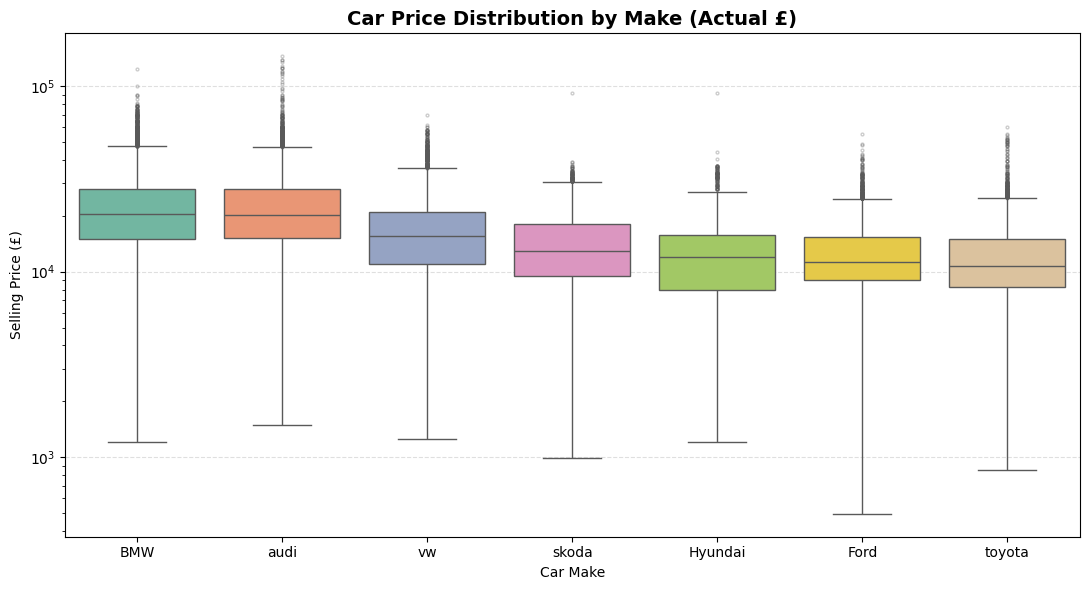

In [ ]:
plot_data = data.copy()

order = (
    plot_data.groupby('Make')['price']
    .median()
    .sort_values(ascending=False)
    .index
)

palette = sns.color_palette('Set2', n_colors=len(order))

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=plot_data, x='Make', y='price',
    order=order, palette=palette,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
plt.title('Car Price Distribution by Make (Actual £)', fontsize=14, fontweight='bold')
plt.xlabel('Car Make')
plt.ylabel('Selling Price (£)')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

